## **sklearn训练模型工作流程**

使用sklearn创建并训练机器学习模型的范式通常为：

**1. 导入模型**：

from sklearn.xxx import xxx

**2. 数据预处理：数据加载、清洗、预处理、数据集划分**

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

**3. 创建模型**：

model = xxx()

**4. 训练模型**：

model.fit(X_train, y_train)

**5. 模型预测**：

y_pred = model.predict(X_test)

score = accuracy_score(y_test, y_pred)


## **传统分类模型**

### **决策树**
根据数据的特征通过对其逐步分裂，以树形结构做出决策，一步步选择，从而将数据分类到不同的类别。

决策树的步骤：
1. **选择一个最佳的特征进行划分**。
   * **核心思想**：通过概率计算，找出能够最好地区分不同类别的数据特征。
   * 选择算法常用的有：ID4, C4.5, CART
  
   * ID4选择的判据是信息增益。
   信息熵：$\mathrm{Ent(D)=-\sum_{i=1}^nP(x_k)\log_2P(x_k)}$
   其中D是样本集合，集合中第k类样本所占比例为$P(x_k)$,假如只有两类，则在两类的概率都取0.5时，信息熵取到最大值。
   
   信息增益：$\mathrm{Gain(D,A)=Ent(D)-\sum_{v=1}^V\frac{D^v}{D}Ent(D^v)}$
   其中D是样本集合，A是特征，$D^v$是特征A取值为v的样本子集，$V$是特征A的取值个数。即用特征A区分前集合D的信息熵减去特征A区分后各小样本空间的加权信息熵。

   * C4.5选择最佳特征的判据是信息增益率。

   信息增益率：$\mathrm{Gain\_ratio(D,A)=\frac{Gain(D,A)}{IV(A)}}$
   其中IV(A)是特征A的固有值。IV(A)=$-\sum_{v=1}^V\frac{|D^v|}{|D|}\log_2\frac{|D^v|}{|D|}$,将特征A的分类数也考虑了进来，避免了为了信息增益的最大化而将特征A无限细分。

   * CART选择最佳特征的判据是基尼指数数。
  
   基尼值度量数据集D的纯度，公式为：$Gini(D)=1-\sum_{k=1}^Kp_k^2$，其中$p_k$是样本集合D中第k类样本所占的比例。基尼值越大表明数据集的纯度越低。

   属性A的基尼指数：$\mathrm{Gini\_index(D,A)=\sum_{v=1}^V\frac{|D^v|}{|D|}Gini(D^v)}$表明了在特征A划分下的（加权）基尼指数，我们要选择的属性A使得属性A的基尼指数最小。

2. **根据这个特征把数据分成不同分支**。
3. **对每个分支重复上述步骤**，直到所有数据被正确分类或没有更多特征可供选择。
4. (可选)**决策树剪枝**。在测试集里划分出一个验证集，来判断剪枝前后识别精确率的变化。
   * **原因**：为了尽可能正确分类训练样本，节点的划分过程会不断重复直到不能再分，这样就可能对训练样本学习的“太好”了，把训练样本的一些特点当做所有数据都具有的一般性质，从而导致过拟合。
   * 预剪枝：在每次划分前后，计算验证集的准确率，当准确率下降时，终止划分。
   * 后剪枝：先将决策树完全构建出来，然后自底向上地对非叶节点进行考察，若将该节点对应的子树替换为叶节点能带来决策树泛化性能的提升，则将该子树替换为叶节点。

In [1]:
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# 加载数据
iris = load_iris()
X, y = iris.data, iris.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# 创建决策树模型

dt = DecisionTreeClassifier(criterion='gini', splitter='best', min_samples_split=5, max_depth=4)
'''
criterion: 用于选择分割节点的标准(默认为"gini"),决定了节点分裂的方式,可以是"gini"(基尼不纯度)或"entropy"(信息增益)。
splitter: 用于选择分割节点的策略(默认为"best"),可以是"best"(最佳分割)或"random"(随机分割)。
max_depth: 树的最大深度(默认为None),用于防止过拟合,None表示节点可以扩展到所有叶节点都是纯的。
min_samples_split: 内部节点再划分所需的最小样本数(默认为2),较小的值会创建更复杂的树。
min_samples_leaf: 叶子节点最少样本数(默认为1),限制了叶子节点的最小尺寸,可以防止过拟合。
max_features: 寻找最佳分割时要考虑的特征数量(默认为None),可以减少过拟合。
random_state: 控制随机性的种子(默认为None),确保结果的可重复性。
max_leaf_nodes: 最大叶子节点数(默认为None),限制了叶子节点的数量,可以防止过拟合。
min_impurity_decrease: 分割节点所需的最小不纯度减少量(默认为0.0),用于控制树的增长。
class_weight: 类别的权重(默认为None),用于处理不平衡数据集,可以设置为"balanced"或字典形式。
'''
# 训练模型
dt.fit(X_train, y_train)

# 示例数据的预测
example = dt.predict([[4.8, 3.0, 1.1, 0.1]])
print('示例数据预测结果:', iris.target_names[example])

# 测试集预测
y_pred = dt.predict(X_test)

# 输出准确率
print(f"测试集准确率: {accuracy_score(y_test, y_pred):.2f}")

示例数据预测结果: ['setosa']
测试集准确率: 0.93


### **随机森林**

由多棵随机生成的决策树组成的模型，大家“投票”决定结果。

In [2]:
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


# 加载数据
iris = load_iris()
X, y = iris.data, iris.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# 创建随机森林模型
rf = RandomForestClassifier(n_estimators=100, criterion='gini', min_samples_split=5, max_depth=4)
'''
n_estimators: 决策树数量(默认100),值越大模型越稳定但计算量越大
criterion: 分裂标准(默认"gini"),可选"gini"或"entropy"
max_depth: 单棵树最大深度(默认None),控制模型复杂度
min_samples_split: 节点分裂最小样本数(默认2),防止过拟合
min_samples_leaf: 叶节点最小样本数(默认1),限制叶节点尺寸
max_features: 分裂时考虑的特征数(默认"sqrt"),控制随机性
bootstrap: 是否使用有放回抽样(默认True),推荐保持
oob_score: 是否使用袋外样本评估(默认False)
n_jobs: 并行任务数(默认None),-1使用全部核心
random_state: 随机种子(默认None),保证结果可复现
class_weight: 类别权重(默认None),处理不平衡数据
max_samples: 每棵树最大样本数(默认None),控制子采样
'''

# 训练模型
rf.fit(X_train, y_train)

# 示例数据的预测
example = rf.predict([[4.8, 3.0, 1.1, 0.1]])
print('示例数据预测结果:', iris.target_names[example])

# 测试集预测
y_pred = rf.predict(X_test)

# 输出准确率
print(f"测试集准确率: {accuracy_score(y_test, y_pred):.2f}")

示例数据预测结果: ['setosa']
测试集准确率: 0.91


### KNN算法(K-Nearest Neighbors)
给定一个待分类的数据点，找到在训练集中与它距离最近的K个数据点，多数邻居是什么类别，新数据就是什么类别。

算法步骤：
1. 计算测试样本与训练集中每个样本的距离，并按照距离的远近排序
2. 选取与当前测试样本最近的k个训练样本，作为该测试样本的邻居
3. 统计这k个样本的类别频次，频次最高的类别，即为测试样本的类别

In [3]:
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [4]:
# 加载数据
iris = load_iris()
X, y = iris.data, iris.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# 创建KNN模型
knn = KNeighborsClassifier(n_neighbors=5)
'''
n_neighbors: 近邻数(默认5),值越大模型越平滑但边界越模糊
weights: 权重计算方式(默认"uniform"),可选"uniform"或"distance"
algorithm: 近邻搜索算法(默认"auto"),可选"auto"、"ball_tree"、"kd_tree"或"brute"
leaf_size: 树结构叶子节点大小(默认30),影响构建/查询速度
p: 闵可夫斯基距离参数(默认2),p=1为曼哈顿距离,p=2为欧氏距离
metric: 距离度量(默认"minkowski"),支持字符串或自定义距离函数
metric_params: 距离度量参数字典(默认None)
n_jobs: 并行任务数(默认None),-1使用全部核心
'''
# 训练模型
knn.fit(X_train, y_train)

# 示例数据的预测
example = knn.predict([[4.8, 3.0, 1.1, 0.1]])
print('示例数据预测结果:', iris.target_names[example])

# 测试集预测
y_pred = knn.predict(X_test)

# 输出准确率
print(f"测试集准确率: {accuracy_score(y_test, y_pred):.2f}")

示例数据预测结果: ['setosa']
测试集准确率: 0.96


### SVM(支持向量机)

支持向量机用于寻找两个类别的最佳决策边界。尽管有多分类问题的变形和回归任务的变形，但其最好的应用是二分类。

<img src="./assets/SVM.png" 
     alt="SVM在二维线性可分空间的示意图" 
     style="width:30%; display: block; margin: 0 auto;" />

**性能指标**：SVM要使两条边界线的间隔d取最大值，其所确定的直线在d/2处。

**支持向量**：两条边界线所插入（触碰）的向量叫支持向量。

**训练数据**：${(X_i,y_i)}$,其中$X_i$是向量，$y_i$是标签，取±1。

这样简单的模型只能解决线性可分的问题，为了解决非线性可分的问题，引入核函数，将数据映射到高维空间。

一般来说，所映射到的维度越高，其可以被一个超平面分开的概率就越大，如果映射到无穷维空间，可以被一个超平面分开的概率为1。

<img src="./assets/凸优化问题.png" 
     alt="SVM将寻找最大间距的超平面的问题转化为这样的凸优化问题" 
     style="width:50%; display: block; margin: 0 auto;" />

SVM将寻找最大间距的超平面的问题转化为这样的凸优化问题，具体的推导过程参考胡浩基老师的课程。

<img src="./assets/引入核函数和正则项.png" 
     alt="SVM引入核函数和正则项" 
     style="width:50%; display: block; margin: 0 auto;" />

#### **SVM的核心参数**
支持向量机(SVM)通过引入核函数和正则项解决非线性分类问题，其核心参数包括：

**C** (正则化参数，默认=1.0)  
‣ 控制模型复杂性与训练误差的权衡：  
 • 低值(C→0)：宽边际 → 允许更多误分类 → 高偏差低方差  
 • 高值(C→∞)：窄边际 → 强制正确分类 → 低偏差高方差  
 ※ 等价于逻辑回归中1/λ，建议测试范围：[0.01, 0.1, 1, 10, 100]

**gamma** (核系数，默认='scale')  
‣ 决定样本影响力的辐射范围：  
 • 低值(γ→0)：平滑边界 → 样本影响范围大 → 简单模型  
 • 高值(γ→∞)：局部拟合 → 样本影响范围小 → 复杂模型  
 ※ 仅作用于非线性核(rbf/poly/sigmoid)，建议测试范围：  
  `scale`=1/(n_features*X.var())  
  `auto`=1/n_features  
  人工设置推荐：[1e-5, 1e-4, ..., 1e1]

<div align="center">

| 核类型   | 公式                      | 适用场景               | 计算复杂度 |
|----------|---------------------------|-----------------------|------------|
| linear   | K(x,y)=xᵀy               | 特征数>>样本量        | O(n)       |
| rbf      | exp(-γ‖x-y‖²)            | 通用非线性问题(默认)  | O(n²)      |
| poly     | (γxᵀy + r)^d             | 需要显式控制复杂度    | O(n²)      |
| sigmoid  | tanh(γxᵀy + r)           | 特殊场景              | O(n²)      |

</div>

#### **SVM在多分类任务的策略**

**直接改造法**（不常用）
- 直接修改优化目标函数和约束条件使其支持多分类
- 实现复杂且计算效率低，实践中很少使用

**一对多策略**（One-vs-Rest, OVR）
假设需要分3类（C1, C2, C3）：
<div align="center">

| 分类器 | 正类 | 负类组合 | 决策规则 |
|--------|------|----------|----------|
| SVM1   | C1   | C2&C3    | f1(X) > 0 → C1 |
| SVM2   | C2   | C1&C3    | f2(X) > 0 → C2 |
| SVM3   | C3   | C1&C2    | f3(X) > 0 → C3 |

</div>

**决策流程**：
> 1. 若只有一个分类器输出>0，直接归入对应类
>  - 例：f1(X)<0, f2(X)>0, f3(X)<0 → C2
> 2. 若多个分类器输出>0，选择置信度最高的类
>  - 例：f1(X)<0, f2(X)>0, f3(X)>0 → max(f2(X), f3(X))

**一对一策略**（One-vs-One, OVO）
假设需要分4类（C1, C2, C3, C4）：

<div align="center">

| 分类器 | 正类 | 负类 | 投票规则 |
|--------|------|------|----------|
| SVM1   | C1   | C2   | f1(X)>0 → C1+1 |
| SVM2   | C1   | C3   | f2(X)>0 → C1+1 |
| SVM3   | C1   | C4   | f3(X)>0 → C1+1 |
| SVM4   | C2   | C3   | f4(X)>0 → C2+1 |
| SVM5   | C2   | C4   | f5(X)>0 → C2+1 |
| SVM6   | C3   | C4   | f6(X)>0 → C3+1 |

</div>

**决策流程**：
- 统计各类得票数，选择票数最多的类
- 最终得分：C1(3), C3(1), C4(2) → 预测为C1

In [5]:
# 导入必要的库
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler  # SVM对数据尺度敏感，建议标准化

# 1. 加载数据
iris = datasets.load_iris()
X, y = iris.data, iris.target

# 2. 数据预处理（SVM对特征尺度敏感，必须做标准化）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 划分训练集和测试集（保持30%测试比例与示例一致）
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.3, 
    random_state=42  # 固定随机种子保证可复现性
)

# 4. 创建SVM模型（使用RBF核，这是最常用的核函数）
svm = SVC(kernel='rbf',C=1.0,gamma='scale',probability=True)
'''
C: 正则化参数(默认1),值越小容忍更多误分类但可能欠拟合
kernel: 核函数类型(默认"rbf"),可选"linear"、"poly"、"rbf"、"sigmoid"或自定义函数
    - "linear": 线性核函数 K(x,y)=x^T y, 适用于线性可分数据
    - "poly": 多项式核函数 K(x,y)=(γx^T y + r)^d, 通过degree参数控制阶数d
    - "rbf": 径向基核函数(高斯核) K(x,y)=exp(-γ||x-y||^2), 最常用的非线性核
    - "sigmoid": 双曲正切核函数 K(x,y)=tanh(γx^T y + r), 类似神经网络激活函数
    - "precomputed": 使用预计算核矩阵, 需提供(n_samples, n_samples)的核矩阵
    - 自定义函数: 接收两个数据点返回标量值, 需满足Mercer条件
degree: 多项式核的阶数(默认3),仅当kernel="poly"时有效
gamma: 核函数系数(默认"scale"),可选"scale"、"auto"或具体数值
coef0: 核函数中的独立项(默认0),影响poly和sigmoid核
shrinking: 是否使用收缩启发式(默认True),可加速训练
probability: 是否启用概率估计(默认False),会减慢训练速度
tol: 停止训练的误差容限(默认0.001)
cache_size: 核缓存大小(MB)(默认200),影响大样本训练速度
class_weight: 类别权重(默认None),可设为"balanced"或字典形式
verbose: 是否输出详细日志(默认False)
max_iter: 最大迭代次数(默认-1表示无限制)
decision_function_shape: 多分类策略(默认"ovr"),可选"ovo"或"ovr"
break_ties: 是否打破平局(默认False),为True时会计算更精确但更慢
random_state: 随机种子(默认None),保证结果可复现
'''
# 5. 训练模型
svm.fit(X_train, y_train)

# 6. 示例数据预测（注意：需要对新数据同样做标准化！）
example = svm.predict(scaler.transform([[4.8, 3.0, 1.1, 0.1]]))
print('示例数据预测结果:', iris.target_names[example])

# 7. 测试集预测
y_pred = svm.predict(X_test)

# 8. 输出准确率（保留2位小数）
print(f"测试集准确率: {accuracy_score(y_test, y_pred):.2f}")

# 可选：输出更详细的分类报告
from sklearn.metrics import classification_report
print("\n分类报告：")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

示例数据预测结果: ['setosa']
测试集准确率: 1.00

分类报告：
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



#### **ROC图和混淆矩阵**

##### ROC图
四个概率TP,FP,TN,FN的关系：
- TP+FN=1 
- TN+FP=1
- 对同一个系统，若TP增加，FP也增加。(若TN增加，FN也增加)

ROC曲线是TPR和FPR的关系图，TPR=TP/(TP+FN)，FPR=FP/(FP+TN)。

<div align="center">
<img src="./assets/ROC曲线.png" 
     alt="ROC曲线" 
     style="width:50%; display: block; margin: 0 auto;" />
</div>

ROC判优标准：
- 曲线越靠近左上角，分类器越优。
- 特别注意曲线和Y轴的交点


##### 混淆矩阵
在一般情况下，我们可以用准确率评估二分类的性能。

但是，试想一下，如果新的审批人有90个需要拒绝，只有10个同意，而用一个只会输出0的模型来审批，计算其准确率发现竟然有90%，这能说明这个模型已经学习的比较好了吗？

二分类的混淆矩阵是一个2x2的方阵，该方阵的左上、左下、右下、右上四个格子里的数分别代表的含义为：

* **真正类 (TP)**：模型正确预测为正类的样本数（0）。
* **假正类 (FP)**：模型错误地将负类预测为正类的样本数（0）。
* **真负类 (TN)**：模型正确预测为负类的样本数（90）。
* **假负类 (FN)**：模型错误地将正类预测为负类的样本数（10）。
  
<div align="center">
<img src="assets/cm_example.png" alt="cm_example" style="zoom:72%;" />
</div>

从混淆矩阵可以看到，在本应该同意审批（AC）的样本里，模型给出拒绝决策的有10个，而同意的却一个也没有，因此模型在AC样本里的效果是很差的。当然，对于不同情况，可以查看其不同指标，分类任务中可以计算的指标有：

* **准确率 (Accuracy)**：所有预测中正确预测的比例。

  $\text{准确率} = \frac{TP + TN}{TP + TN + FP + FN} = 0.9$​

* **精确率 (Precision)**：模型预测为正类的样本中，真正为正类的比例。

  $\text{精确率} = \frac{TP}{TP + FP} = 0$

* **召回率 (Recall)**：真实为正类的样本中，被正确预测为正类的比例。

  $\text{召回率} = \frac{TP}{TP + FN} = 0$

* **F1-score**：精确率和召回率的调和平均值，综合评估模型的性能，尤其在类别不平衡的情况下。

  $\text{F1-score} = 2 \times \frac{\text{精确率} \times \text{召回率}}{\text{精确率} + \text{召回率}} = 0$

可以看到，上述模型除了准确率以外，其它指标都很差。

混淆矩阵:
[[8 0]
 [2 0]]


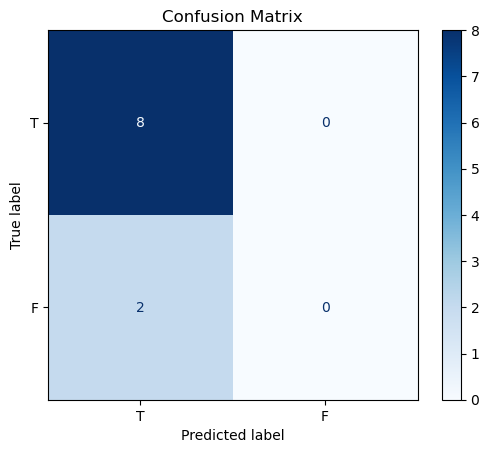

准确率:  0.8
精确率:  1.0
召回率:  0.0
f1-score:  0.0


In [7]:
# 绘制混淆矩阵
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#
y_test = [0, 0, 0, 0, 0, 0, 0, 1, 1, 0]  # 真实标签
y_pred = [0,0,0,0,0,0,0,0,0,0]  # 预测标签
# 计算混淆矩阵
cm = confusion_matrix(y_test, y_pred)

# 输出混淆矩阵
print("混淆矩阵:")
print(cm)

# 绘制混淆矩阵
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['T', 'F'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

print('准确率: ', accuracy_score(y_test, y_pred))
print('精确率: ', precision_score(y_test, y_pred,zero_division=1))
print('召回率: ', recall_score(y_test, y_pred))
print('f1-score: ', f1_score(y_test, y_pred))


### 朴素贝叶斯分类器
贝叶斯定理：
$$
P(C_i|X) = \frac{P(X|C_i)P(C_i)}{P(X)}
$$
其中$C_i$是类别，可以取$C1,C2……$，$X$是要分类的向量，可以写成$[x_1,x_2,....,x_n]$。

其中$P(C_i)$是先验概率，$P(C_i|X)$是$X$在$C_i$上的后验概率，$P(X|C_i)$是$X$在$C_i$上的条件概率。

所有的概率分类法都是估计$P(X|C_i)$，以此来得到$P(C_i|X)$的估计。

**朴素贝叶斯**分类器有两点假设：
1. 特征之间相互独立
2. 每个特征的取值都是离散的
因此，我们可以将$P(X|C_i)$表示为
$$
P(X|C_i) = \prod_{j=1}^n P(x_j|C_i)
$$
其中$P(x_j|C_i)$可以在已知的$C_i$中通过采样的方法得到。



In [ ]:
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB  # 高斯朴素贝叶斯
from sklearn.model_selection import train_test_split

# 加载数据
iris = load_iris()
X, y = iris.data, iris.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建朴素贝叶斯模型（高斯分布假设）
nb = GaussianNB()
'''
高斯朴素贝叶斯参数说明：
- priors: 手动指定类别的先验概率（默认None，自动计算）
- var_smoothing: 方差平滑项（默认1e-9），防止零方差问题

其他变体（根据数据类型选择）：
1. MultinomialNB: 适用于离散特征（如文本词频）
2. BernoulliNB: 适用于二值特征（如是否出现）
3. ComplementNB: 适用于不平衡文本数据
'''

# 训练模型
nb.fit(X_train, y_train)

# 示例数据的预测
example = nb.predict([[4.8, 3.0, 1.1, 0.1]])  # 输入样本特征
print('示例数据预测结果:', iris.target_names[example])  # 输出类别名称

# 测试集预测
y_pred = nb.predict(X_test)

# 输出准确率
print(f"测试集准确率: {accuracy_score(y_test, y_pred):.2f}")

# 输出预测概率（朴素贝叶斯的优势之一）
example_proba = nb.predict_proba([[4.8, 3.0, 1.1, 0.1]])
print('示例数据预测概率:', dict(zip(iris.target_names, example_proba[0])))

示例数据预测结果: ['setosa']
测试集准确率: 0.98
示例数据预测概率: {'setosa': 1.0, 'versicolor': 2.388835829996588e-17, 'virginica': 7.43485845942104e-26}
